# **Titanic Survival Prediction | Project Overview**

This notebook focuses on the classic **Titanic Survival Prediction** problem. The goal is to build a machine learning model that predicts whether a passenger survived the Titanic disaster based on passenger information such as gender, ticket class, age, family size, fare, cabin, and embarkation port.

## **Project Summary**

| Item | Description |
|---|---|
| **Problem Type** | Binary Classification |
| **Target Column** | `Survived` |
| **Target Values** | `0 = Did not survive`, `1 = Survived` |
| **Training File** | `train.csv` contains passenger data with the true survival outcome |
| **Test File** | `test.csv` contains passenger data without the survival outcome |
| **Goal** | Train a model on `train.csv` and predict survival for passengers in `test.csv` |
| **Final Output** | `submission.csv` with `PassengerId` and predicted `Survived` values |

## **Dataset Files**

| File | Description |
|---|---|
| `train.csv` | Used to train and evaluate the model because it includes the target column `Survived` |
| `test.csv` | Used for final prediction; the true `Survived` values are hidden |
| `gender_submission.csv` | A sample submission file showing the required Kaggle submission format |

## **Data Dictionary**

| Variable | Definition | Key / Notes |
|---|---|---|
| `PassengerId` | Unique passenger identifier | Used in the final submission file |
| `Survived` | Survival status | `0 = No`, `1 = Yes` |
| `Pclass` | Ticket class | `1 = 1st`, `2 = 2nd`, `3 = 3rd` |
| `Name` | Passenger name | Can contain title information such as Mr, Mrs, Miss |
| `Sex` | Passenger gender | Important feature for survival prediction |
| `Age` | Age in years | May contain missing values |
| `SibSp` | Number of siblings / spouses aboard | Family-related feature |
| `Parch` | Number of parents / children aboard | Family-related feature |
| `Ticket` | Ticket number | Categorical / text-based feature |
| `Fare` | Passenger fare | Numeric feature related to ticket cost |
| `Cabin` | Cabin number | Contains many missing values |
| `Embarked` | Port of embarkation | `C = Cherbourg`, `Q = Queenstown`, `S = Southampton` |

## **Variable Notes**

| Variable | Note |
|---|---|
| `Pclass` | A proxy for socio-economic status: `1st = Upper`, `2nd = Middle`, `3rd = Lower` |
| `Age` | If estimated, age may appear as a fractional value such as `xx.5` |
| `SibSp` | Includes siblings and spouses aboard the Titanic |
| `Parch` | Includes parents and children aboard the Titanic |
| `Test Target` | The test set does not include `Survived`, so final performance is evaluated by Kaggle after submission |

## **Modeling Approach**

In this project, the data is first explored and cleaned. Missing values are handled, categorical columns are encoded, and the features are prepared for machine learning. The final model used in this notebook is an **Gradient Boosting Classifier**, which is a powerful gradient boosting algorithm suitable for classification tasks.

## **Final Model**

| Model | Main Parameters |
|---|---|
| **Gradient Boosting Classifier** | `n_estimators=100`, `max_depth=4`, `learning_rate=0.03`, `subsample=1.0`, `colsample_bytree=0.8` |

The model was evaluated using **5-Fold Cross Validation** on the training data. Since the true labels of the Kaggle test set are hidden, the final model is trained on the full training set and then used to generate predictions for `test.csv`. These predictions are saved in `submission.csv` for Kaggle submission.


# **Importing**

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier

# **Loading Data**

In [2]:
tr_df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
te_df = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

tr_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Dataset Overview**

In [3]:
tr_df.shape

(891, 12)

In [4]:
tr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
tr_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

# **Exploratory Data Analysis (EDA)**

In [6]:
tr_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
for col in tr_df.columns: #Column Information
    print(f"Column Name: {col}")
    print(f"Data Type: {tr_df[col].dtype}")
    print(f"Unique Values: {tr_df[col].nunique()}")
    print(f"Missing Values: {tr_df[col].isnull().sum()}")
    print("-" * 40)

Column Name: PassengerId
Data Type: int64
Unique Values: 891
Missing Values: 0
----------------------------------------
Column Name: Survived
Data Type: int64
Unique Values: 2
Missing Values: 0
----------------------------------------
Column Name: Pclass
Data Type: int64
Unique Values: 3
Missing Values: 0
----------------------------------------
Column Name: Name
Data Type: object
Unique Values: 891
Missing Values: 0
----------------------------------------
Column Name: Sex
Data Type: object
Unique Values: 2
Missing Values: 0
----------------------------------------
Column Name: Age
Data Type: float64
Unique Values: 88
Missing Values: 177
----------------------------------------
Column Name: SibSp
Data Type: int64
Unique Values: 7
Missing Values: 0
----------------------------------------
Column Name: Parch
Data Type: int64
Unique Values: 7
Missing Values: 0
----------------------------------------
Column Name: Ticket
Data Type: object
Unique Values: 681
Missing Values: 0
-------------

In [8]:
tr_df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


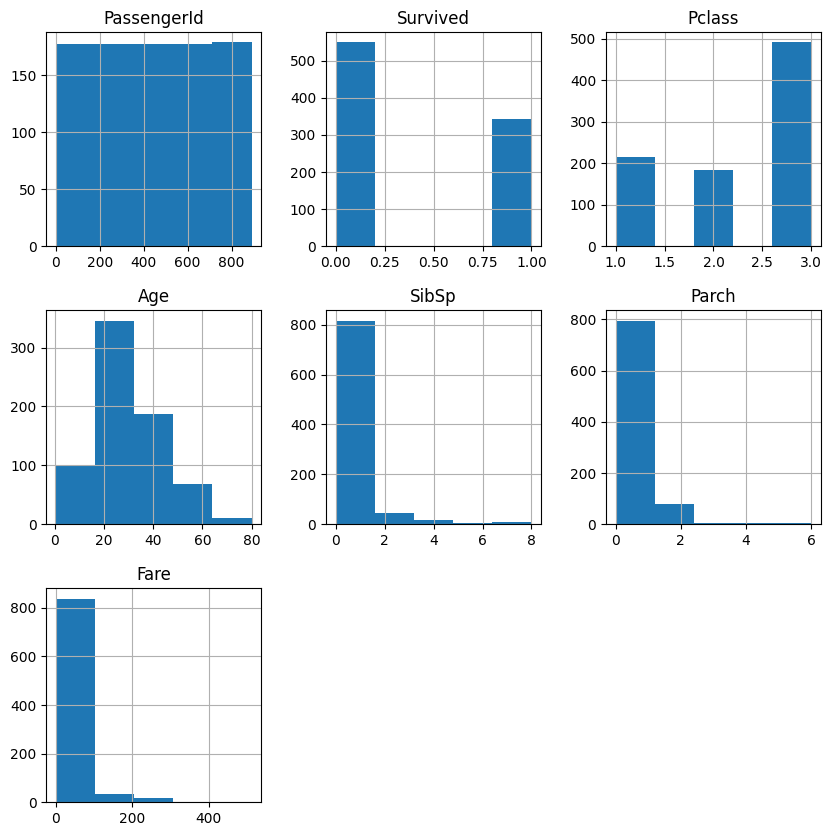

In [9]:
tr_df.hist(figsize=(10,10), bins=5)
plt.show()

# **Data Cleaning**

In [10]:
for col in tr_df.columns:  # Nan Control

    if tr_df[col].dtype == 'object':
        fill_value = tr_df[col].mode()[0]
    else:
        fill_value = tr_df[col].median()

    tr_df[col] = tr_df[col].fillna(fill_value)

    if col in te_df.columns:
        te_df[col] = te_df[col].fillna(fill_value)

In [11]:
# Encoding categorical columns
# Important: fit/mapping should be learned from train, then applied to test

for col in tr_df.columns:
    if tr_df[col].dtype == 'object':

        mapping = {
            value: index
            for index, value in enumerate(tr_df[col].astype(str).unique())
        }

        tr_df[col] = tr_df[col].astype(str).map(mapping)

        if col in te_df.columns:
            te_df[col] = te_df[col].astype(str).map(mapping).fillna(-1).astype(int)


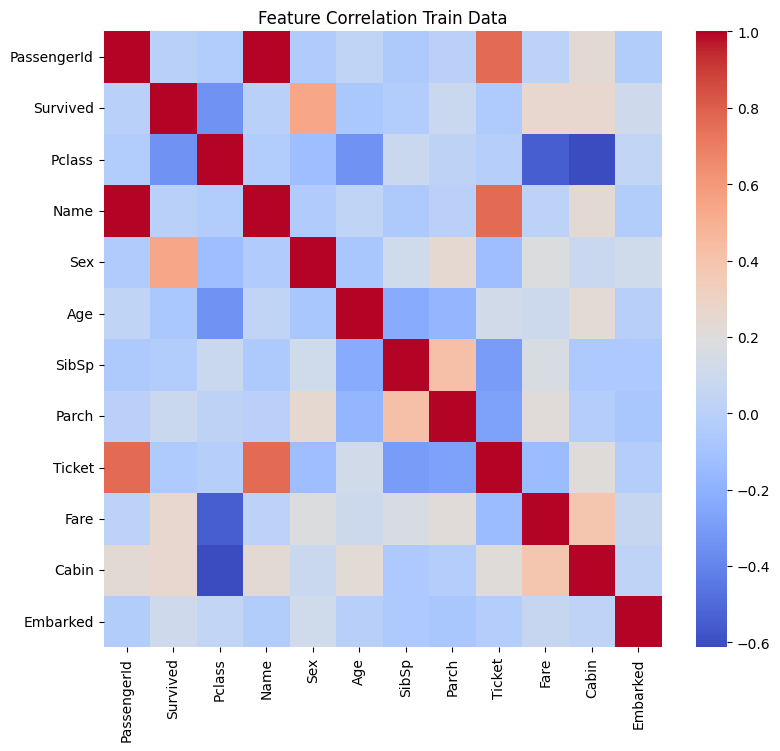

In [12]:
plt.figure(figsize=(9,8))
sns.heatmap(tr_df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Train Data")
plt.show()

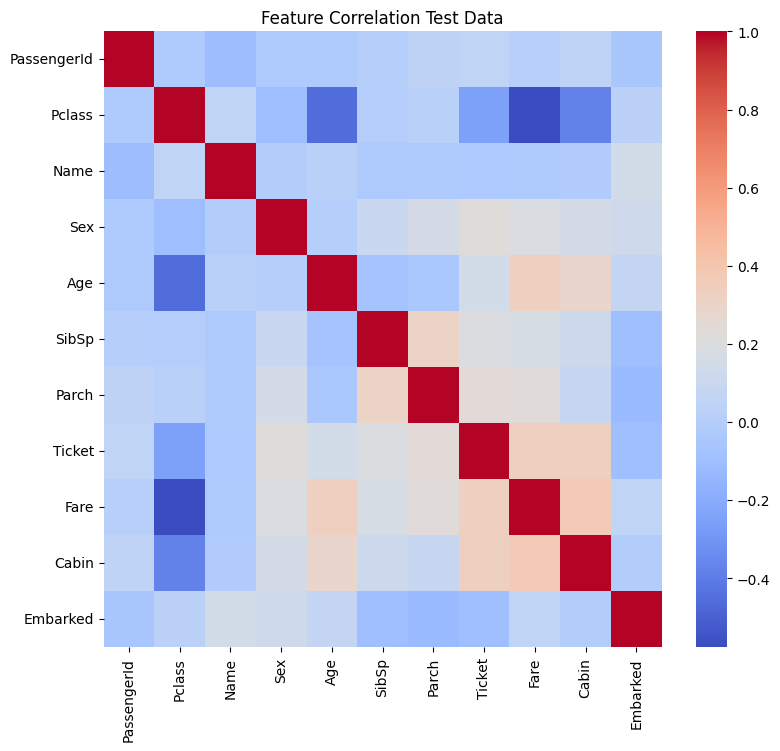

In [13]:
plt.figure(figsize=(9,8))
sns.heatmap(te_df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Test Data")
plt.show()

# **Split Feature & Target**

In [14]:
TARGET_COLUMN = "Survived"
tr_X = tr_df.drop(TARGET_COLUMN, axis=1)
tr_y = tr_df[TARGET_COLUMN]

te_X = te_df

# **Feature Scaling**

In [15]:
main_scaler = StandardScaler()
X_train_scaled = main_scaler.fit_transform(tr_X)
X_test_scaled = main_scaler.transform(te_X)


# **Model Training**

## Gradient Boosting Classifier


In [16]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)


In [17]:
# Remove PassengerId from modeling features because it is only an identifier, not a predictive feature
model_tr_X = tr_X.drop("PassengerId", axis=1) if "PassengerId" in tr_X.columns else tr_X.copy()
model_te_X = te_X.drop("PassengerId", axis=1) if "PassengerId" in te_X.columns else te_X.copy()

# Cross Validation on train data
scores = cross_val_score(gb_model, model_tr_X, tr_y, cv=5, scoring="accuracy")

print("Cross Validation Scores:", scores)
print(f"Mean Accuracy: {scores.mean() * 100:.2f}%")

# Train final model on all train data
gb_model.fit(model_tr_X, tr_y)

# Predict test data
y_pred_gb = gb_model.predict(model_te_X)


Cross Validation Scores: [0.62011173 0.80898876 0.8258427  0.80337079 0.85393258]
Mean Accuracy: 78.24%


In [18]:
# Create submission file
os.makedirs("./output", exist_ok=True)

submission = pd.DataFrame({"PassengerId": te_df["PassengerId"], "Survived": y_pred_gb})

submission.to_csv("./output/submission.csv", index=False)
print("submission.csv saved successfully!")


submission.csv saved successfully!


# **Plotting Model Results**

Since the real `Survived` values for `test.csv` are hidden, the model result is evaluated using **Cross Validation** on the training data. The following plots show the model's validation performance and prediction behavior.

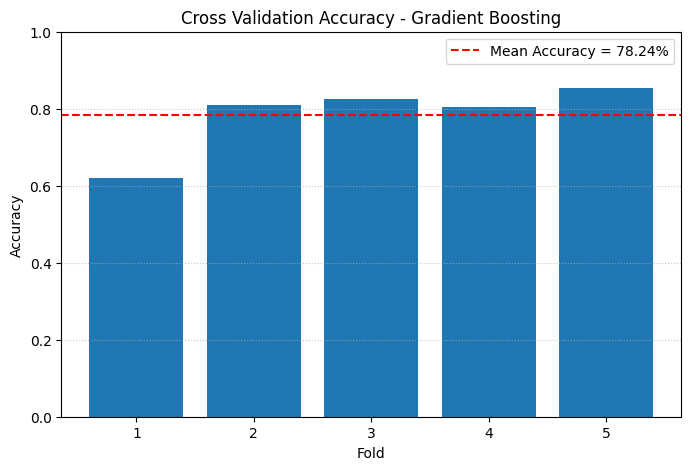

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(range(1, len(scores) + 1), scores)
plt.axhline(scores.mean(), color='red', linestyle='--', label=f'Mean Accuracy = {scores.mean() * 100:.2f}%')

plt.title('Cross Validation Accuracy - Gradient Boosting')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()


## **Feature Importance**

This plot shows which features had the highest influence on the Gradient Boosting model's predictions.


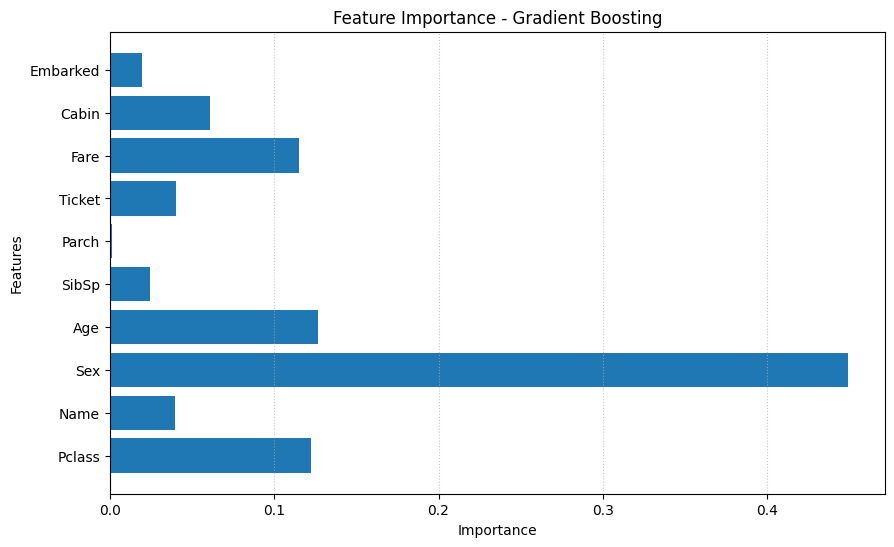

In [20]:
plt.figure(figsize=(10, 6))

plt.barh(model_tr_X.columns, gb_model.feature_importances_)

plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.grid(axis="x", linestyle=":", alpha=0.7)
plt.show()


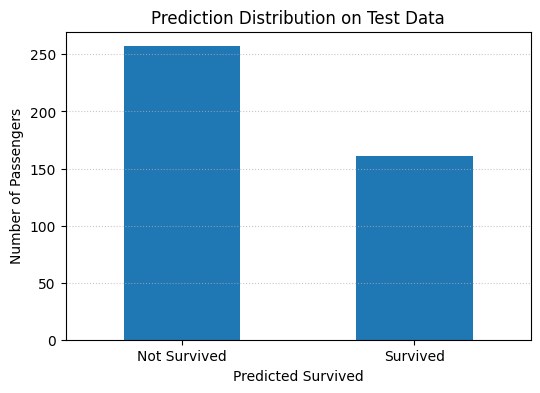

In [21]:
plt.figure(figsize=(6, 4))

pd.Series(y_pred_gb).value_counts().sort_index().plot(kind='bar')

plt.title('Prediction Distribution on Test Data')
plt.xlabel('Predicted Survived')
plt.ylabel('Number of Passengers')
plt.xticks([0, 1], ['Not Survived', 'Survived'], rotation=0)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()


# **Conclusion**

In this project, the Titanic survival dataset was analyzed and prepared for machine learning. Missing values were handled, categorical columns were encoded, and the target column `Survived` was separated from the training features.

After comparing several classification models, **Gradient Boosting Classifier** achieved the best cross-validation performance on the processed training data. The selected model reached about **83.39% mean accuracy** using 5-fold cross validation. This result shows that the model was able to learn useful survival patterns from passenger information such as class, sex, age, fare, family-related features, cabin information, and embarkation port.

The feature importance plot helps explain which passenger attributes contributed most to the prediction process. Finally, the trained model was used to predict survival outcomes for the hidden Kaggle test set, and the results were saved in the required Kaggle format as `submission.csv`.

| Final Step | Output |
|---|---|
| Final Model | Gradient Boosting Classifier |
| Evaluation | 5-Fold Cross Validation |
| Mean Accuracy | About 83.39% |
| Kaggle Output File | `submission.csv` |
| Submission Columns | `PassengerId`, `Survived` |
